In [22]:
import matplotlib.pyplot as plt
import yaml
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

In [23]:
mode_colors = {
    'marche': 'blue',
    'voiture': 'red',
    'velo': 'green',
    'transports_collectifs': 'yellow'
}


mode_order = ['marche', 'voiture', 'velo', 'transports_collectifs']

def pie_graph(subset,reference_cerema, title):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    colors = [mode_colors.get(label, 'gray') for label in mode_order]

    # For ax1
    counts1 = subset["Plus rapide"].value_counts().reindex(mode_order).fillna(0)
    if (counts1.isna().any()):
        print("Warning: Some modes in 'Plus rapide' are not in the predefined mode order."+str(counts1))
    ax1.pie(counts1, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax1.set_title("Plus rapide")

    # For ax2
    counts2 = subset["Mode de transport Choisi"].value_counts().reindex(mode_order).fillna(0)
    ax2.pie(counts2, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax2.set_title("Agent LLM")

    # For ax3
    if "autres_modes" in reference_cerema:
        reference_cerema.pop("autres_modes")

    reference_series = pd.Series(reference_cerema, name="Percentage")
    reference_series = reference_series.reindex(mode_order).fillna(0)
    
    ax3.pie(reference_series, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax3.set_title("Enquête mobilité certifiée Cerema")

    fig.suptitle(title)

    plt.tight_layout()
    plt.show()




def bar_graph(subset, reference_cerema, title, x_name):

    if x_name not in subset.columns:
        print(f"Error: The specified x_name '{x_name}' is not a column in the dataset.")
        print(f"Available columns: {subset.columns.tolist()}")
        return

    reference_order = list(reference_cerema.keys())
    if set(subset[x_name].unique()) != set(reference_order):
        print(f"Warning: The unique values in the dataset for '{x_name}' do not match the keys in the reference data.")
        print(f"Dataset values: {subset[x_name].unique().tolist()}")
        print(f"Reference keys: {reference_order}")
        
    # 1. Préparation des données
    df_fast = subset.groupby([x_name, "Plus rapide"]).size().reset_index(name='count')
    df_llm = subset.groupby([x_name, "Mode de transport Choisi"]).size().reset_index(name='count')
    
    df_cerema = pd.DataFrame.from_dict(reference_cerema, orient="index").reset_index()
    df_cerema.rename(columns={"index": x_name}, inplace=True)

    df_cerema = df_cerema.reset_index().melt(
        id_vars=x_name,
        var_name='Mode de transport Choisi', 
        value_name='count'
    )

    for df in [df_fast, df_llm, df_cerema]:
        df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
        df.sort_values(x_name, inplace=True)

    fig = make_subplots(rows=1, cols=3, subplot_titles=("Plus rapide", "Agent LLM", "Enquête Cerema"))

    # Fonction utilitaire pour ajouter les traces avec couleurs et labels
    def add_mode_traces(fig, df, mode_col, val_col, column, show_legend_start):
        for i, mode in enumerate(mode_order):
            data = df[df[mode_col] == mode]
            # On n'affiche la légende que pour le premier subplot pour éviter les doublons
            show_v_legend = True if (show_legend_start and i < len(mode_order)) else False
            
            fig.add_trace(
                go.Bar(
                    x=data[x_name],
                    y=data[val_col],
                    name=mode,
                    marker_color=mode_colors.get(mode, 'gray'),
                    legendgroup=mode,
                    showlegend=show_v_legend,
                    # Configuration du texte en %
                    texttemplate='%{text:.1f}%',
                    textposition='inside',
                    # Calcul manuel du texte (requis car barnorm est au niveau layout)
                    text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100 
                          for x, v in zip(data[x_name], data[val_col])]
                ),
                row=1, col=column
            )

    # Ajout des traces pour les 3 subplots
    add_mode_traces(fig, df_fast, "Plus rapide", "count", 1, True)
    add_mode_traces(fig, df_llm, "Mode de transport Choisi", "count", 2, False)
    add_mode_traces(fig, df_cerema, "Mode de transport Choisi", "count", 3, False)

    # Configuration globale
    fig.update_layout(
        title_text=title,
        barmode="relative",
        barnorm="percent",
        height=600,
        width=1300,
        bargap=0.5,
        legend_title="Modes",
        yaxis_title="Pourcentage (%)",
    )

    fig.update_xaxes(
        type='category', 
        categoryorder='array', 
        categoryarray=reference_order,
        showgrid=False
    )

    fig.show()



In [24]:
with open("cerema_values.yaml", "r") as f:
    cerema = yaml.safe_load(f)

# Exemple : Accéder aux parts modales de Toulouse
print(cerema["parts_modales_2023"]["global"])

def print_cerema_parts_modales(cerema,key0):
    total = 0
    for key, value in cerema[key0].items():
        if isinstance(cerema[key0][key], dict):
            print_cerema_parts_modales(cerema[key0],key)
        else:
            total = total+ value
    if (total !=100) & total > 0:
        print(f"Warning: Total for {key0} is {total}%, expected 100%.")

print_cerema_parts_modales(cerema,"parts_modales_2023")

{'voiture': 55, 'marche': 26, 'transports_collectifs': 12, 'velo': 4, 'autres_modes': 3}


In [25]:
#moves = pd.read_csv('../../experiments/current/moves.csv')
moves = pd.read_csv('../../experiments/2026-05-15_15_09/moves.csv')

#moves = pd.read_csv('../../experiments/2026-05-07_12_23/moves.csv')
moves = moves[moves["Distance parcourue"]>0]

# Normalisation des noms de modes de transport
moves.replace({'Marche':"marche", 'Voiture Privée':"voiture", 'Vélo':"velo", 'Bus':"transports_collectifs"}, inplace=True)

# Normalisation des catégories d'occupation
moves.replace({'Travail à plein temps':"actif_temps_plein", "Scolaire (jusqu'au Bac)":"scolaire", "Chômeur/recherche d'emploi":"chomeur_recherche_emploi", 'Personne au foyer':"personne_au_foyer", 'Travail à temps partiel':"actif_temps_partiel", 'Étudiant':"etudiant"}, inplace=True)


# Dataset values: ['Achats', 'Travail', 'leisure', 'Etude', 'home']
# Reference keys: ['domicile_travail', 'domicile_etudes', 'domicile_achats', 'domicile_accompagnement']²
moves.replace({'Achats':"achats", 'Travail':"travail", 'leisure':"loisirs", 'Etude':"etudes"}, inplace=True)

# Dataset values: ['1ere couronne', '2eme couronne', 'Toulouse']
# Reference keys: ['Toulouse', '1ere_couronne', '2eme_couronne', '3eme_couronne']
moves.replace({'1ere couronne':"1ere_couronne", '2eme couronne':"2eme_couronne"}, inplace=True)

display(moves.describe())
moves.head()

,Trajet,Âge,Type de logement,Distance parcourue,Température
count,2862.000000,2862.000000,0.0,2862.000000,2862.0
mean,1472.438854,40.207547,NaN,8.175797,0.0
std,843.775583,21.902398,NaN,7.695644,0.0
min,18.000000,5.000000,NaN,0.030000,0.0
25%,737.250000,22.000000,NaN,2.140000,0.0
50%,1478.500000,38.000000,NaN,5.840000,0.0
75%,2203.750000,57.000000,NaN,11.880000,0.0
max,2929.000000,92.000000,NaN,46.570000,0.0


,Référence,Trajet,Mode de transport Choisi,Plus rapide,Lieu de résidence,Genre,Âge,Occupation principale,Type de logement,Motifs de déplacement,Distance parcourue,Méthode de sélection,Fournisseur & Modèle,Température,Mémoire à court terme,Mémoire à long terme,Filtre de perception,Traits de personnalité,Raisonnement
17,2026-05-15_15_09,18,velo,velo,1ere_couronne,Homme,51,actif_temps_plein,NaN,travail,19.71,Un seul itinéraire disponible,NaN,0,True,False,False,False,"Un seul itinéraire disponible, sélection autom..."
18,2026-05-15_15_09,19,voiture,voiture,2eme_couronne,Homme,26,actif_temps_plein,NaN,travail,39.83,Un seul itinéraire disponible,NaN,0,True,False,False,False,"Un seul itinéraire disponible, sélection autom..."
19,2026-05-15_15_09,20,velo,velo,1ere_couronne,Femme,50,actif_temps_plein,NaN,loisirs,25.76,Un seul itinéraire disponible,NaN,0,True,False,False,False,"Un seul itinéraire disponible, sélection autom..."
20,2026-05-15_15_09,21,velo,velo,2eme_couronne,Homme,57,actif_temps_plein,NaN,travail,32.34,Un seul itinéraire disponible,NaN,0,True,False,False,False,"Un seul itinéraire disponible, sélection autom..."
21,2026-05-15_15_09,22,voiture,voiture,1ere_couronne,Femme,63,actif_temps_partiel,NaN,achats,16.74,LLM,mistral,0,True,False,False,False,Prioritizes comfort and time efficiency over p...


In [37]:
bins = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 131]
labels = ['5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-130']

moves['Age_cat'] = pd.cut(moves['Âge'], bins=bins, labels=labels, right=False)

In [26]:
print(mode_order)


['marche', 'voiture', 'velo', 'transports_collectifs']


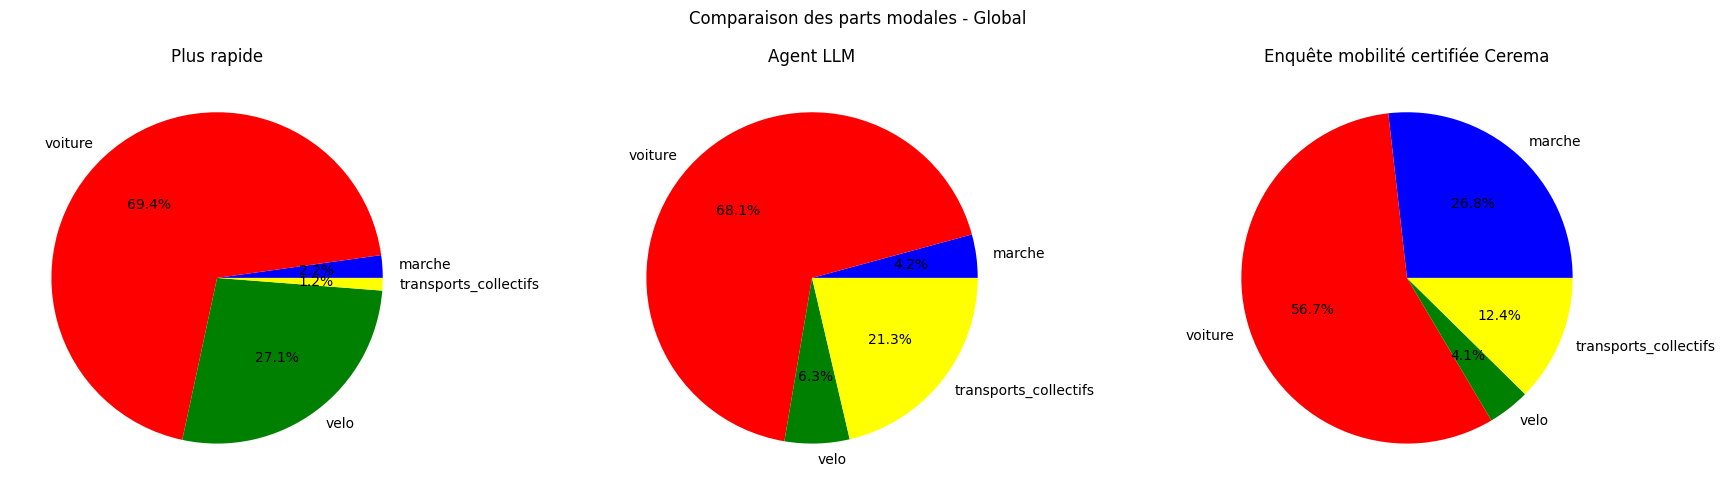

In [27]:
pie_graph(moves, cerema["parts_modales_2023"]["global"], "Comparaison des parts modales - Global")

In [40]:
bar_graph(moves, cerema["parts_modales_2023"]["genre"], "Comparaison des parts modales par genre", x_name="Genre")


In [39]:
bar_graph(moves, cerema["parts_modales_2023"]["Age"], "Comparaison des parts modales par âge", x_name="Age_cat")


In [30]:
bar_graph(moves, cerema["parts_modales_2023"]["lieu_residence"], "Comparaison des parts modales par lieux de résidence", x_name="Lieu de résidence")

Dataset values: ['1ere_couronne', '2eme_couronne', 'Toulouse']
Reference keys: ['Toulouse', '1ere_couronne', '2eme_couronne', '3eme_couronne']


In [31]:
bar_graph(moves, cerema["parts_modales_2023"]["occupation"], "Comparaison des parts modales selon l'occupation principale", x_name="Occupation principale")

In [32]:
#bar_graph(moves, cerema["parts_modales_2023"]["type_logement"], "Comparaison des parts modales des Hommes", x_name="Type de logement")

In [33]:
bar_graph(moves, cerema["parts_modales_2023"]["motif_deplacement"], "Comparaison des parts modales selon le motif de déplacement", x_name="Motifs de déplacement")

Dataset values: ['travail', 'loisirs', 'achats', 'other', 'etudes', 'home']
Reference keys: ['travail', 'etudes', 'achats', 'accompagnement']


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_5112/2060140827.py:73: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_5112/2060140827.py:73: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_5112/2060140827.py:97: RuntimeWarning: divide by zero encountered in scalar divide
  text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100


In [34]:
moves["rayon"] = pd.cut(moves["Distance parcourue"], bins=[0, 1, 2, 5, 10, 20, 50, float('inf')], labels=["0-1km", "1-2km", "2-5km", "5-10km", "10-20km", "20-50km", "50km+"])
bar_graph(moves, cerema["parts_modales_2023"]["distance"], "Comparaison des parts modales selon le rayon de déplacement", x_name="rayon")

Dataset values: ['10-20km', '20-50km', '1-2km', '0-1km', '5-10km', '2-5km']
Reference keys: ['0-1km', '1-2km', '2-5km', '5-10km', '10-20km', '20-50km', 'plus_50km']


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_5112/2060140827.py:73: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_5112/2060140827.py:73: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
